# 🏥 Healthcare Patient Analytics & Risk Analysis System

## Phase 1 — Day 1: Data Understanding

### Objective

The objective of this day is to understand the healthcare
patient dataset before performing any data cleaning or analysis.

We will examine:

- Dataset size
- Columns
- Data types
- Missing values
- Duplicate rows
- Numerical statistics
- Categorical variables
- Patient demographics
- Initial distributions


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully.")

Libraries imported successfully.


In [7]:
df = pd.read_csv("/content/healthcare_patients.csv")

print("Dataset loaded successfully.")
df.head()

Dataset loaded successfully.


,patient_id,age,gender,blood_pressure,heart_rate,bmi,smoking_status,diabetes,hypertension,disease,admission_type,length_of_stay,medication_count,treatment_cost,readmission,risk_score
0,103475,84,Female,144.0,81.0,21.2,Current,No,No,Healthy/Preventive,Urgent,5,2.0,19148.0,No,45.9
1,105328,42,Male,130.0,104.0,34.2,Never,No,No,Hypertension,Emergency,7,3.0,28092.0,No,42.5
2,102009,56,Female,127.0,71.0,28.8,Current,Yes,Yes,Other,Urgent,7,8.0,20706.0,No,56.4
3,104186,54,Female,148.0,70.0,31.8,Never,No,Yes,Diabetes,Emergency,5,6.0,25249.0,No,62.9
4,108876,57,Male,130.0,96.0,26.7,Never,No,No,Healthy/Preventive,Elective,3,4.0,14612.0,No,28.2


In [13]:
# First dataset inspection
df.shape
df.columns
df.info()
df.dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10020 entries, 0 to 10019
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   patient_id        10020 non-null  int64  
 1   age               10020 non-null  int64  
 2   gender            10020 non-null  object 
 3   blood_pressure    9870 non-null   float64
 4   heart_rate        9900 non-null   float64
 5   bmi               9840 non-null   float64
 6   smoking_status    9920 non-null   object 
 7   diabetes          10020 non-null  object 
 8   hypertension      10020 non-null  object 
 9   disease           10020 non-null  object 
 10  admission_type    10020 non-null  object 
 11  length_of_stay    10020 non-null  int64  
 12  medication_count  9900 non-null   float64
 13  treatment_cost    9940 non-null   float64
 14  readmission       10020 non-null  object 
 15  risk_score        10020 non-null  float64
dtypes: float64(6), int64(3), object(7)
memor

,0
patient_id,int64
age,int64
gender,object
blood_pressure,float64
heart_rate,float64
bmi,float64
smoking_status,object
diabetes,object
hypertension,object
disease,object


In [17]:
# Missing values
df.isnull().sum()
df.isnull().sum().sum()

np.int64(750)

In [20]:
# Duplicate rows
df.duplicated().sum()

np.int64(20)

In [48]:
# Numerical statistics
df.describe()

print(df['gender'].value_counts(),
df['disease'].value_counts(),
df['admission_type'].value_counts(),
df['smoking_status'].value_counts(),
df["readmission"].value_counts())

gender
Male      4937
Female    4896
Other      187
Name: count, dtype: int64 disease
Hypertension           1886
Healthy/Preventive     1804
Diabetes               1610
Heart Disease          1148
Other                  1132
Respiratory Disease    1125
Kidney Disease          675
Cancer                  640
Name: count, dtype: int64 admission_type
Elective     4375
Emergency    3171
Urgent       2474
Name: count, dtype: int64 smoking_status
Never      5716
Former     2466
Current    1738
Name: count, dtype: int64 readmission
No     7952
Yes    2068
Name: count, dtype: int64


In [22]:
# Categorical variables
df.describe(include=['object'])

,gender,smoking_status,diabetes,hypertension,disease,admission_type,readmission
count,10020,9920,10020,10020,10020,10020,10020
unique,3,3,2,2,8,3,2
top,Male,Never,No,No,Hypertension,Elective,No
freq,4937,5716,8055,7156,1886,4375,7952


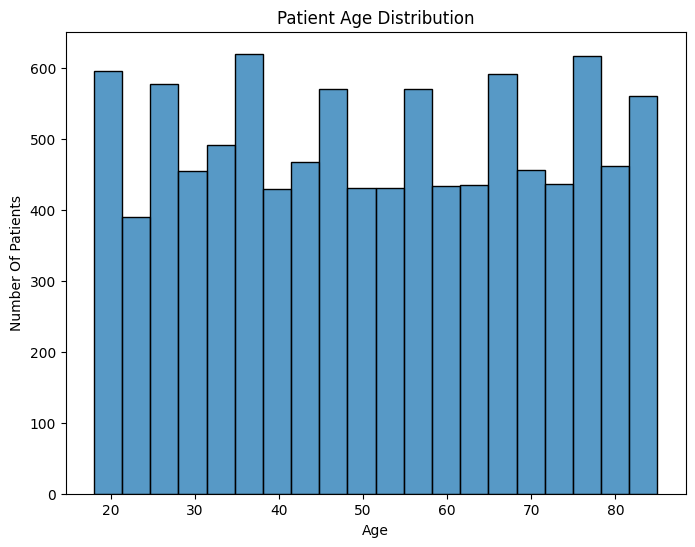

In [32]:
# First visualization
plt.figure(figsize=(8,6))
sns.histplot(data=df, x='age', bins=20)
plt.title('Patient Age Distribution')
plt.xlabel('Age')
plt.ylabel('Number Of Patients')
plt.show()

In [33]:
# Data quality summary
data_summary = pd.DataFrame({
    "data_type": df.dtypes,
    "missing_values": df.isnull().sum(),
    "unique_values": df.nunique()
})

data_summary

,data_type,missing_values,unique_values
patient_id,int64,0,10000
age,int64,0,68
gender,object,0,3
blood_pressure,float64,150,99
heart_rate,float64,120,79
bmi,float64,180,268
smoking_status,object,100,3
diabetes,object,0,2
hypertension,object,0,2
disease,object,0,8


In [35]:
df.shape
df.nunique()

,0
patient_id,10000
age,68
gender,3
blood_pressure,99
heart_rate,79
bmi,268
smoking_status,3
diabetes,2
hypertension,2
disease,8


In [45]:
# Missing value percentage
missing_percentage = (
    df.isnull().sum() / len(df) * 100
)

missing_percentage
missing_percentage[missing_percentage > 0]



,0
blood_pressure,1.497006
heart_rate,1.197605
bmi,1.796407
smoking_status,0.998004
medication_count,1.197605
treatment_cost,0.798403


In [50]:
df.describe()

,patient_id,age,blood_pressure,heart_rate,bmi,length_of_stay,medication_count,treatment_cost,risk_score
count,10020.000000,10020.000000,9870.000000,9900.000000,9840.000000,10020.000000,9900.000000,9940.000000,10020.000000
mean,104996.770160,51.518164,128.272543,77.924747,26.305467,6.499601,2.817778,29976.888632,46.426647
std,2887.254587,19.607287,17.645118,11.869977,4.974323,3.191824,1.856322,15480.652599,18.262592
min,100001.000000,18.000000,90.000000,45.000000,15.000000,1.000000,0.000000,800.000000,1.000000
25%,102496.750000,34.000000,116.000000,70.000000,22.900000,4.000000,1.000000,18679.500000,33.400000
50%,104993.500000,51.000000,128.000000,78.000000,26.300000,6.000000,3.000000,27953.000000,45.200000
75%,107497.250000,69.000000,140.000000,86.000000,29.600000,8.000000,4.000000,38959.750000,58.400000
max,110000.000000,85.000000,190.000000,127.000000,45.000000,22.000000,12.000000,101926.000000,100.000000


## 📋 Day 1 Observations

### Dataset Size

- Number of rows: 10,020
- Number of columns: 16
- The dataset contains 20 duplicate rows.

### Data Types

- Numerical variables: 9
- Categorical variables: 7

### Data Quality

- Total missing values: 750
- Missing values are present in blood_pressure, heart_rate, bmi,
  smoking_status, medication_count, and treatment_cost.
- Duplicate rows: 20

### Patient Demographics

- Most common gender: Male
- Male and Female records are relatively close in number.
- Patient ages range from 18 to 85 years.
- Mean patient age: approximately 51.52 years.

### Disease Information

- Most common disease category: Hypertension
- Hypertension is followed by Healthy/Preventive and Diabetes.

### Admission Information

- Most common admission type: Elective
- Emergency admissions are the second most common category.

### Smoking Status

- Most common smoking status: Never
- Former smokers are more common than Current smokers.

### Readmission

- Most records have a readmission status of No.
- 2,068 records have a readmission status of Yes.

### Numerical Variables

- Mean BMI: approximately 26.31
- Mean heart rate: approximately 77.92
- Mean length of stay: approximately 6.50 days
- Mean medication count: approximately 2.82
- Mean treatment cost: approximately ₹29,976.89
- Mean risk score: approximately 46.43

### Initial Observation

The dataset contains a mixture of demographic, clinical,
admission, treatment, cost, and risk-related variables. It also
contains intentionally introduced missing values and duplicate
records, which will be handled during the data cleaning phase.